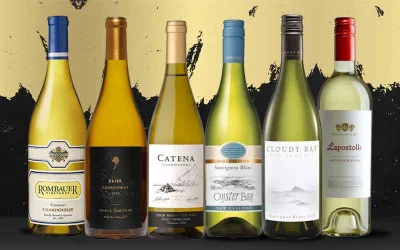

# **Wine Quality Dataset**

1.   นาย กฤษดา ยอดสุรางค์	6609611741
2.   นาย จักรรินทร์ สังข์อ่อง	6609611782






# **ข้อ 3 การเตรียมข้อมูล (Preprocessing)**

In [2]:
import pandas as pd
from sklearn.preprocessing import RobustScaler

url = "https://raw.githubusercontent.com/Jakarinx-san/WineQuality-Classification/refs/heads/main/winequality-red.csv"
df = pd.read_csv(url, sep=';')

print(df.head(10))
print()
print(df.isnull().sum())

#Missing Value
missing_values = df.isnull().sum().sum()
print(f"จำนวน Missing Values ทั้งหมดในชุดข้อมูล: {missing_values} จุด")

#Noise Removal & Encoding
X = df.drop(columns=['quality'])
y = df['quality']
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0) #แปลง target quality จาก Numerical เป็น Categorical

#Scaling
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   
5            7.4              0.66         0.00             1.8      0.075   
6            7.9              0.60         0.06             1.6      0.069   
7            7.3              0.65         0.00             1.2      0.065   
8            7.8              0.58         0.02             2.0      0.073   
9            7.5              0.50         0.36             6.1      0.071   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0

# **ข้อ 4 Feature Selection & Importance**

**Importance**

Dataset Loaded
Samples: 1599
Total Features: 11

Baseline AUC (All Features): 0.9475

Using 2/3 Rule → Selecting top 8 features out of 11
AUC after retraining (2/3 features): 0.9456

AUC-Based Permutation Importance Ranking
   rank               feature  auc_importance_mean  auc_importance_std
0     1               alcohol             0.108817            0.020056
1     2             sulphates             0.064532            0.010649
2     3  total sulfur dioxide             0.044776            0.010046
3     4      volatile acidity             0.036926            0.009385
4     5         fixed acidity             0.022426            0.005261
5     6   free sulfur dioxide             0.017629            0.003703
6     7               density             0.012458            0.004670
7     8        residual sugar             0.007984            0.003535





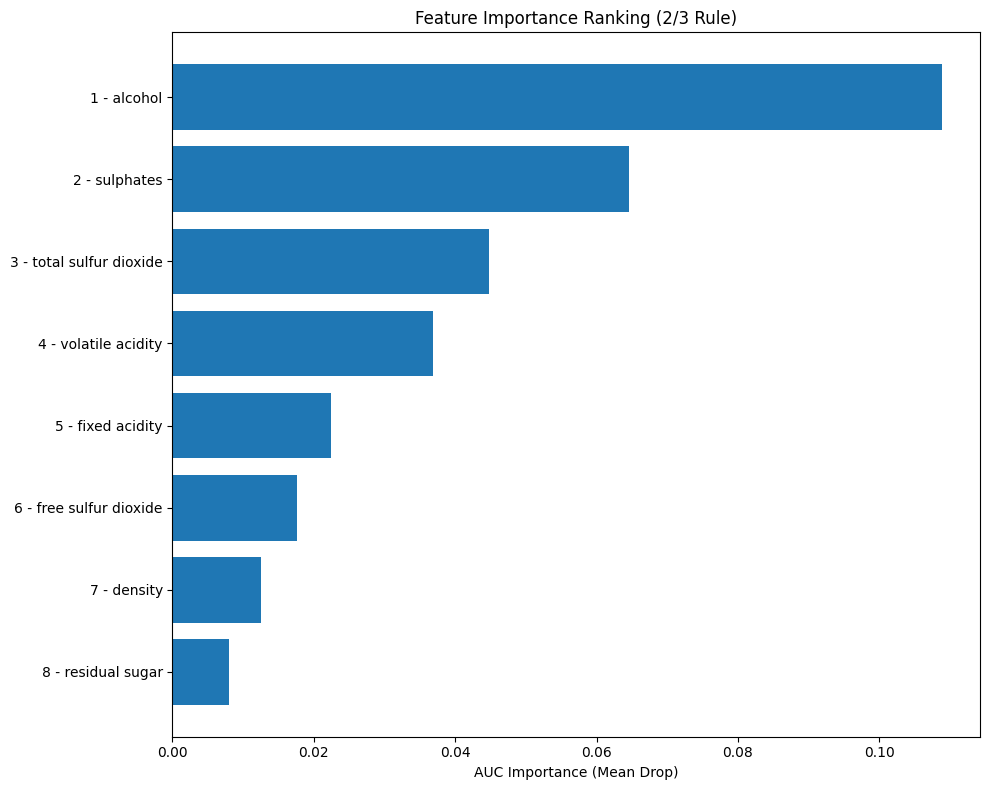


Pipeline Completed Successfully (2/3 Rule)


In [3]:
# ============================================
# XGBoost + AUC-based Permutation Importance
# Dynamic 2/3 Feature Selection Rule
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier


# ============================================
# 1. Load Dataset
# ============================================

X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

print("======================================")
print("Dataset Loaded")
print("Samples:", X.shape[0])
print("Total Features:", X.shape[1])
print("======================================")


# ============================================
# 2. Train / Validation Split
# ============================================

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


# ============================================
# 3. Train Initial XGBoost Model
# ============================================

model_full = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

model_full.fit(X_train, y_train)

baseline_auc = roc_auc_score(
    y_val,
    model_full.predict_proba(X_val)[:, 1]
)

print("\nBaseline AUC (All Features):", round(baseline_auc, 4))


# ============================================
# 4. Tree-based Ranking (GAIN)
# ============================================

booster = model_full.get_booster()
score_dict = booster.get_score(importance_type="gain")

tree_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": [score_dict.get(f, 0) for f in X.columns]
}).sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)


# ============================================
# 5. Dynamic 2/3 Feature Selection
# ============================================

total_features = X.shape[1]
k = int(np.ceil((2/3) * total_features))

selected_features = tree_importance.head(k)["feature"].tolist()

print(f"\nUsing 2/3 Rule → Selecting top {k} features out of {total_features}")


# ============================================
# 6. Retrain Model with Selected Features
# ============================================

model_selected = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

model_selected.fit(X_train[selected_features], y_train)

selected_auc = roc_auc_score(
    y_val,
    model_selected.predict_proba(X_val[selected_features])[:, 1]
)

print("AUC after retraining (2/3 features):", round(selected_auc, 4))


# ============================================
# 7. AUC-Based Permutation Importance
# ============================================

perm = permutation_importance(
    model_selected,
    X_val[selected_features],
    y_val,
    n_repeats=50,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": selected_features,
    "auc_importance_mean": perm.importances_mean,
    "auc_importance_std": perm.importances_std
}).sort_values(
    by="auc_importance_mean",
    ascending=False
).reset_index(drop=True)

importance_df["rank"] = importance_df.index + 1

importance_df = importance_df[[
    "rank",
    "feature",
    "auc_importance_mean",
    "auc_importance_std"
]]


# ============================================
# 8. Display Ranking
# ============================================

print("\n======================================")
print("AUC-Based Permutation Importance Ranking")
print("======================================")
print(importance_df)
print("\n\n")

# ============================================
# 9. Plot Importance
# ============================================

plt.figure(figsize=(10, 8))

labels = importance_df["rank"].astype(str) + " - " + importance_df["feature"]

plt.barh(labels, importance_df["auc_importance_mean"])
plt.xlabel("AUC Importance (Mean Drop)")
plt.title("Feature Importance Ranking (2/3 Rule)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nPipeline Completed Successfully (2/3 Rule)")


**Feature Selection**

In [4]:
# ============================================
# Nested Cross-Validation with XGBoost
# + Mean / Median Feature Selection Summary
# ============================================

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier

# ============================================
# 1. Load Dataset
# ============================================

print("======================================")
print("Dataset Loaded")
print("Samples:", X.shape[0])
print("Features:", X.shape[1])
print("======================================\n")

# ============================================
# 2. Define Outer and Inner CV
# ============================================

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

outer_results = []
outer_best_k = []

min_k = 5


# ============================================
# 3. Outer Loop (Model Evaluation)
# ============================================

for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):

    print(f"===== Outer Fold {fold_idx+1} =====")

    X_train_outer = X.iloc[train_idx]
    y_train_outer = y.iloc[train_idx]

    X_test_outer = X.iloc[test_idx]
    y_test_outer = y.iloc[test_idx]

    # ----------------------------------------
    # Step A: Train model for tree importance
    # ----------------------------------------
    model_full = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )

    model_full.fit(X_train_outer, y_train_outer)

    booster = model_full.get_booster()
    score_dict = booster.get_score(importance_type="gain")

    importance_values = [
        score_dict.get(col, 0) for col in X.columns
    ]

    sorted_features = pd.DataFrame({
        "feature": X.columns,
        "importance": importance_values
    }).sort_values(
        by="importance",
        ascending=False
    )["feature"].tolist()

    # ----------------------------------------
    # Step B: Inner CV to find best_k
    # ----------------------------------------
    performance_records = []

    for k in range(min_k, len(sorted_features) + 1):

        selected_features = sorted_features[:k]
        fold_scores = []

        for inner_train_idx, inner_val_idx in inner_cv.split(
            X_train_outer, y_train_outer
        ):

            X_tr = X_train_outer.iloc[inner_train_idx][selected_features]
            y_tr = y_train_outer.iloc[inner_train_idx]

            X_va = X_train_outer.iloc[inner_val_idx][selected_features]
            y_va = y_train_outer.iloc[inner_val_idx]

            model = XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss",
                n_jobs=-1
            )

            model.fit(X_tr, y_tr)
            preds = model.predict(X_va)

            fold_scores.append(accuracy_score(y_va, preds))

        mean_score = np.mean(fold_scores)
        performance_records.append((k, mean_score))

    performance_df = pd.DataFrame(
        performance_records,
        columns=["num_features", "cv_accuracy"]
    )

    best_k = performance_df.loc[
        performance_df["cv_accuracy"].idxmax(),
        "num_features"
    ]

    print("Best k from Inner CV:", best_k)

    outer_best_k.append(best_k)

    # ----------------------------------------
    # Step C: Retrain with best_k on full outer train
    # ----------------------------------------
    best_features = sorted_features[:best_k]

    final_model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )

    final_model.fit(
        X_train_outer[best_features],
        y_train_outer
    )

    outer_preds = final_model.predict(
        X_test_outer[best_features]
    )

    outer_acc = accuracy_score(y_test_outer, outer_preds)

    print("Outer Fold Accuracy:", round(outer_acc, 4), "\n")

    outer_results.append(outer_acc)


# ============================================
# 4. Final Nested CV Summary
# ============================================

print("======================================")
print("Nested CV Results")
print("======================================")

outer_results = np.array(outer_results)
outer_best_k = np.array(outer_best_k)

print("Outer Fold Accuracies:", np.round(outer_results, 4))
print("Mean Nested CV Accuracy:", round(np.mean(outer_results), 4))
print("Std Nested CV Accuracy:", round(np.std(outer_results), 4))

print("\nBest k chosen per fold:", outer_best_k.tolist())

mean_k = np.mean(outer_best_k)
median_k = np.median(outer_best_k)
std_k = np.std(outer_best_k)
min_k_val = np.min(outer_best_k)
max_k_val = np.max(outer_best_k)

print("\n--- Feature Count Statistics ---")
print("Mean best k:", round(mean_k, 2))
print("Median best k:", int(median_k))
print("Std of best k:", round(std_k, 2))
print("Min best k:", min_k_val)
print("Max best k:", max_k_val)

recommended_k = int(median_k)
print("\nRecommended number of features (Median-based):", recommended_k)

print("\nNested CV Completed Successfully")


Dataset Loaded
Samples: 1599
Features: 11

===== Outer Fold 1 =====
Best k from Inner CV: 10
Outer Fold Accuracy: 0.9094 

===== Outer Fold 2 =====
Best k from Inner CV: 9
Outer Fold Accuracy: 0.925 

===== Outer Fold 3 =====
Best k from Inner CV: 10
Outer Fold Accuracy: 0.9187 

===== Outer Fold 4 =====
Best k from Inner CV: 10
Outer Fold Accuracy: 0.8875 

===== Outer Fold 5 =====
Best k from Inner CV: 9
Outer Fold Accuracy: 0.9216 

Nested CV Results
Outer Fold Accuracies: [0.9094 0.925  0.9188 0.8875 0.9216]
Mean Nested CV Accuracy: 0.9125
Std Nested CV Accuracy: 0.0135

Best k chosen per fold: [10, 9, 10, 10, 9]

--- Feature Count Statistics ---
Mean best k: 9.6
Median best k: 10
Std of best k: 0.49
Min best k: 9
Max best k: 10

Recommended number of features (Median-based): 10

Nested CV Completed Successfully


แสดงคุณลักษณะที่เหลือหลังจากทําขันตอน Feature Selection

จำนวนที่แนะนำ: 10 คุณลักษณะ
['alcohol', 'sulphates', 'volatile acidity', 'density', 'total sulfur dioxide', 'fixed acidity', 'citric acid', 'free sulfur dioxide', 'residual sugar', 'chlorides']


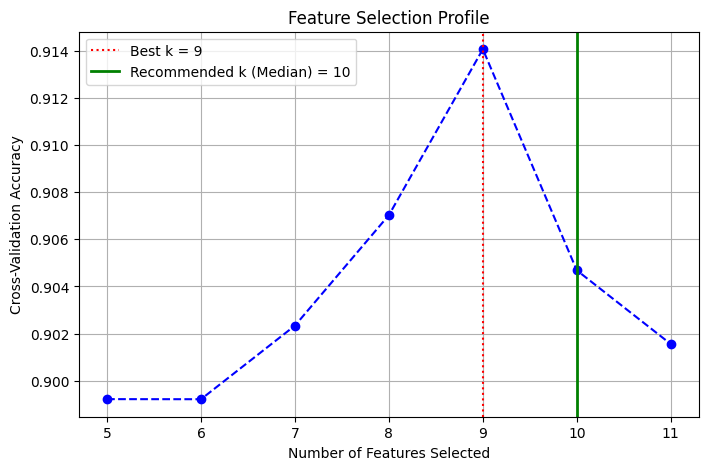

In [5]:
recommended_features = sorted_features[:recommended_k]
print(f"จำนวนที่แนะนำ: {recommended_k} คุณลักษณะ")
print(recommended_features)
print("=" * 50)

plt.figure(figsize=(8, 5))
plt.title(f'Feature Selection Profile')
plt.xlabel('Number of Features Selected')
plt.ylabel('Cross-Validation Accuracy')
plt.plot(performance_df["num_features"], performance_df["cv_accuracy"], marker='o', color='b', linestyle='--')
plt.axvline(x=best_k, color='r', linestyle=':', label=f'Best k = {best_k}')
plt.axvline(x=recommended_k, color='g', linestyle='-', linewidth=2, label=f'Recommended k (Median) = {recommended_k}')
plt.legend()
plt.grid(True)
plt.show()

# **ข้อ 5 การออกแบบการทดลอง**




In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# แบ่งข้อมูล 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"ขนาดชุดข้อมูลสร้างแบบจำลอง (Train/CV): {X_train_scaled.shape[0]} ตัวอย่าง")
print(f"ขนาดชุดข้อมูลทดสอบ (Test/Evaluation): {X_test_scaled.shape[0]} ตัวอย่าง")

ขนาดชุดข้อมูลสร้างแบบจำลอง (Train/CV): 1279 ตัวอย่าง
ขนาดชุดข้อมูลทดสอบ (Test/Evaluation): 320 ตัวอย่าง


# **ข้อ 6 เทคนิคการจำแนกประเภท**

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

param_grids = {
    'kNN': {
        'model': KNeighborsClassifier(),
        'params': {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
    },
    'XGBoost': {
        'model': XGBClassifier(eval_metric='logloss', random_state=42),
        'params': {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1]}
    },
    'NeuralNetwork': {
        'model': MLPClassifier(max_iter=1000, random_state=42),
        'params': {'hidden_layer_sizes': [(50,), (100,)], 'alpha': [0.0001, 0.05]}
    }
}

# **ข้อ 7 Hyperparameter Tuning**

In [12]:
from sklearn.model_selection import GridSearchCV

best_models = {}

for model_name, config in param_grids.items():

    grid_search = GridSearchCV(estimator=config['model'],
                               param_grid=config['params'],
                               cv=5,
                               scoring='f1',
                               n_jobs=-1)

    grid_search.fit(X_train_scaled, y_train)

    best_models[model_name] = grid_search.best_estimator_

    print(f"Best Parameters ของ {model_name}: {grid_search.best_params_}")

Best Parameters ของ kNN: {'n_neighbors': 5, 'weights': 'distance'}
Best Parameters ของ XGBoost: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Best Parameters ของ NeuralNetwork: {'alpha': 0.0001, 'hidden_layer_sizes': (100,)}


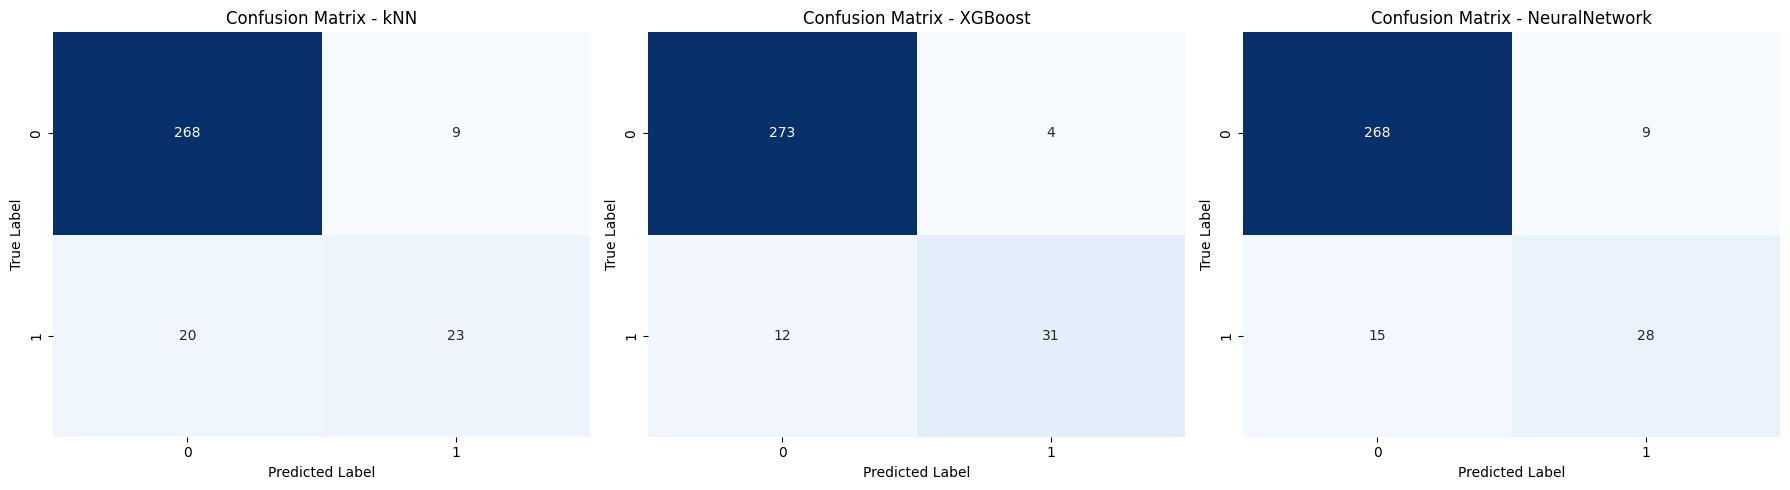

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(18, 5))

for i, (name, model) in enumerate(best_models.items()):
    y_test_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_test_pred)

    plt.subplot(1, len(best_models), i + 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()

plt.show()

# **ข้อ 8 การประเมินประสิทธิภาพ**

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

summary_list = []

print("=== รายงานผลการทดสอบโมเดล (Model Evaluation Report) ===")
print("เปรียบเทียบระหว่าง Training (Cross-Validation) และ Test Set (Evaluation)\n")

for name, model in best_models.items():
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    acc_train = accuracy_score(y_train, y_train_pred)
    prec_train = precision_score(y_train, y_train_pred, average='weighted')
    rec_train = recall_score(y_train, y_train_pred, average='weighted')
    f1_train = f1_score(y_train, y_train_pred, average='weighted')

    acc_test = accuracy_score(y_test, y_test_pred)
    prec_test = precision_score(y_test, y_test_pred, average='weighted')
    rec_test = recall_score(y_test, y_test_pred, average='weighted')
    f1_test = f1_score(y_test, y_test_pred, average='weighted')

    diff = acc_train - acc_test

    print(f"โมเดล: {name}")
    print(f"{'Metrics':<12} | {'Train Set':<12} | {'Test Set':<12}")
    print("-" * 50)
    print(f"{'Accuracy':<12} | {acc_train:<12.4f} | {acc_test:<12.4f}")
    print(f"{'Precision':<12} | {prec_train:<12.4f} | {prec_test:<12.4f}")
    print(f"{'Recall':<12} | {rec_train:<12.4f} | {rec_test:<12.4f}")
    print(f"{'F1-Score':<12} | {f1_train:<12.4f} | {f1_test:<12.4f}")

    if diff > 0.10:
        diagnosis = "Overfitting (โมเดลจำข้อมูลเก่าได้ดีเกินไป แต่ตอบข้อมูลใหม่ไม่เก่ง)"
    elif acc_train < 0.60:
        diagnosis = "Underfitting (โมเดลยังเรียนรู้ความสัมพันธ์ของข้อมูลได้ไม่เพียงพอ)"
    else:
        diagnosis = "Good Fit (โมเดลเรียนรู้ได้ดีและนำไปใช้ทำนายข้อมูลใหม่ได้เสถียร)"

    print(f"สถานะ: {diagnosis}")
    print(f"ส่วนต่าง Accuracy: {diff:.4f}")
    print("=" * 60 + "\n")

    summary_list.append({
        'Model': name,
        'Train Acc': acc_train,
        'Test Acc': acc_test,
        'Gap': diff,
        'Status': diagnosis
    })

print("ตารางสรุปเปรียบเทียบทุกโมเดล:")
summary_df = pd.DataFrame(summary_list)
display(summary_df)

=== รายงานผลการทดสอบโมเดล (Model Evaluation Report) ===
เปรียบเทียบระหว่าง Training (Cross-Validation) และ Test Set (Evaluation)

โมเดล: kNN
Metrics      | Train Set    | Test Set    
--------------------------------------------------
Accuracy     | 1.0000       | 0.9094      
Precision    | 1.0000       | 0.9021      
Recall       | 1.0000       | 0.9094      
F1-Score     | 1.0000       | 0.9036      
สถานะ: Good Fit (โมเดลเรียนรู้ได้ดีและนำไปใช้ทำนายข้อมูลใหม่ได้เสถียร)
ส่วนต่าง Accuracy: 0.0906

โมเดล: XGBoost
Metrics      | Train Set    | Test Set    
--------------------------------------------------
Accuracy     | 1.0000       | 0.9500      
Precision    | 1.0000       | 0.9482      
Recall       | 1.0000       | 0.9500      
F1-Score     | 1.0000       | 0.9478      
สถานะ: Good Fit (โมเดลเรียนรู้ได้ดีและนำไปใช้ทำนายข้อมูลใหม่ได้เสถียร)
ส่วนต่าง Accuracy: 0.0500

โมเดล: NeuralNetwork
Metrics      | Train Set    | Test Set    
--------------------------------------------------
A

,Model,Train Acc,Test Acc,Gap,Status
0,kNN,1.000000,0.909375,0.090625,Good Fit (โมเดลเรียนรู้ได้ดีและนำไปใช้ทำนายข้อ...
1,XGBoost,1.000000,0.950000,0.050000,Good Fit (โมเดลเรียนรู้ได้ดีและนำไปใช้ทำนายข้อ...
2,NeuralNetwork,0.982017,0.925000,0.057017,Good Fit (โมเดลเรียนรู้ได้ดีและนำไปใช้ทำนายข้อ...


# **ข้อ 9 สรุปและการเลือกโมเดล**

In [10]:
from sklearn.metrics import classification_report, f1_score

model_results = {}

for name, model in best_models.items():
    y_test_pred = model.predict(X_test_scaled)
    current_f1 = f1_score(y_test, y_test_pred, average='weighted')

    model_results[name] = {
        'test_f1': current_f1,
        'y_pred': y_test_pred
    }

best_model_name = max(model_results, key=lambda k: model_results[k]['test_f1'])

print(f"สรุปโมเดลที่เหมาะสมที่สุด (Best Model): {best_model_name}")
print(f"เหตุผล: ให้ค่า F1-Score สูงสุดที่ {model_results[best_model_name]['test_f1']:.4f} ซึ่งหมายความว่าโมเดลนี้มีความสามารถสูงสุดเมื่อเทียบกับโมเดลอื่นๆ")
print("-" * 50)

print(f"รายงานประสิทธิภาพของ {best_model_name}:")
print(classification_report(y_test, model_results[best_model_name]['y_pred']))

สรุปโมเดลที่เหมาะสมที่สุด (Best Model): XGBoost
เหตุผล: ให้ค่า F1-Score สูงสุดที่ 0.9478 ซึ่งหมายความว่าโมเดลนี้มีความสามารถสูงสุดเมื่อเทียบกับโมเดลอื่นๆ
--------------------------------------------------
รายงานประสิทธิภาพของ XGBoost:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       277
           1       0.89      0.72      0.79        43

    accuracy                           0.95       320
   macro avg       0.92      0.85      0.88       320
weighted avg       0.95      0.95      0.95       320

